<a href="https://colab.research.google.com/github/paskasiregar/adaptive-xai-credit/blob/main/home_credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1: Get data, auth, lib

In [40]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
base_path = '/content/drive/MyDrive/[all] thesis/Colab Notebooks/home-credit-default-risk'

df = pd.read_csv(f'{base_path}/application_train.csv')
desc = pd.read_csv(f'{base_path}/HomeCredit_columns_description.csv', encoding='latin-1')

print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


* `base_path`: A variable storing the full folder path (so no need to type it out every time).
* `pd.read_csv(...application_train.csv)`: Loads main dataset into df. 307,511 rows, 122 columns. This is what will train and run SHAP on.
* `pd.read_csv(...HomeCredit_columns_description.csv)`: Loads the column descriptions into desc. This is the lookup table that tells what each column name actually means in plain English.

In [42]:
desc[desc['Table'] == 'application_{train|test}.csv'][['Row', 'Description']]

,Row,Description
0,SK_ID_CURR,ID of loan in our sample
1,TARGET,Target variable (1 - client with payment diffi...
2,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving
3,CODE_GENDER,Gender of the client
4,FLAG_OWN_CAR,Flag if the client owns a car
...,...,...
117,AMT_REQ_CREDIT_BUREAU_DAY,Number of enquiries to Credit Bureau about the...
118,AMT_REQ_CREDIT_BUREAU_WEEK,Number of enquiries to Credit Bureau about the...
119,AMT_REQ_CREDIT_BUREAU_MON,Number of enquiries to Credit Bureau about the...
120,AMT_REQ_CREDIT_BUREAU_QRT,Number of enquiries to Credit Bureau about the...


# 2: Inspection + Cleaning

## 2a: Inspection

In [43]:
# Check class imbalance
print("Target distribution:")
print(df['TARGET'].value_counts())
print()

# Check missing values - top 20 worst columns
print("Top 20 columns by missing value %:")
print((df.isnull().mean() * 100).sort_values(ascending=False).head(20).round(2))

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Top 20 columns by missing value %:
COMMONAREA_AVG              69.87
COMMONAREA_MODE             69.87
COMMONAREA_MEDI             69.87
NONLIVINGAPARTMENTS_MEDI    69.43
NONLIVINGAPARTMENTS_MODE    69.43
NONLIVINGAPARTMENTS_AVG     69.43
FONDKAPREMONT_MODE          68.39
LIVINGAPARTMENTS_AVG        68.35
LIVINGAPARTMENTS_MEDI       68.35
LIVINGAPARTMENTS_MODE       68.35
FLOORSMIN_MODE              67.85
FLOORSMIN_AVG               67.85
FLOORSMIN_MEDI              67.85
YEARS_BUILD_AVG             66.50
YEARS_BUILD_MODE            66.50
YEARS_BUILD_MEDI            66.50
OWN_CAR_AGE                 65.99
LANDAREA_MEDI               59.38
LANDAREA_AVG                59.38
LANDAREA_MODE               59.38
dtype: float64


"Check missing values - top 20 worst columns" -> this is to see which columns have the most missing data, ranked worst to best.

For example, `COMMONAREA_AVG = 69.87` means 69.87% of applicants have no value in that column. Nearly 7 out of 10 rows are blank for that feature.

### 2a.1: Verifying the `COMMONAREA_AVG`

In [44]:
desc = pd.read_csv(f"{base_path}/HomeCredit_columns_description.csv", encoding='latin-1')
desc

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
...,...,...,...,...,...
214,217,installments_payments.csv,NUM_INSTALMENT_NUMBER,On which installment we observe payment,NaN
215,218,installments_payments.csv,DAYS_INSTALMENT,When the installment of previous credit was su...,time only relative to the application
216,219,installments_payments.csv,DAYS_ENTRY_PAYMENT,When was the installments of previous credit p...,time only relative to the application
217,220,installments_payments.csv,AMT_INSTALMENT,What was the prescribed installment amount of ...,NaN


In [45]:
desc[desc['Row'].isin(['COMMONAREA_AVG'])]

,Unnamed: 0,Table,Row,Description,Special
48,51,application_{train|test}.csv,COMMONAREA_AVG,Normalized information about building where th...,normalized


In [46]:
df[['SK_ID_CURR', 'COMMONAREA_AVG']]

,SK_ID_CURR,COMMONAREA_AVG
0,100002,0.0143
1,100003,0.0605
2,100004,NaN
3,100006,NaN
4,100007,NaN
...,...,...
307506,456251,0.0202
307507,456252,0.0022
307508,456253,0.0123
307509,456254,NaN


This is to see how many `COMMONAREA_AVG` values are NaN (missing).

## 2b: Cleaning

In [47]:
threshold = 0.4
df_clean = df[df.columns[df.isnull().mean() < threshold]] #df_clean is one big table: 307,511 rows, 73 columns. It contains everything: the inputs (income, loan amount, employment length, etc) AND the answer (did this person default or not).

# Need to split them apart because the model's job is to learn: "given the inputs, predict the answer." If the answer is sitting inside the inputs, the model just reads it directly and learns nothing.

print("Columns before:", df.shape[1])
print("Columns after:", df_clean.shape[1])
print("Columns dropped:", df.shape[1] - df_clean.shape[1])

Columns before: 122
Columns after: 73
Columns dropped: 49


Drop columns missing more than 40% of values.

**What this step does:** Identifies and removes columns with too much missing data, then prepares the dataframe for model training.

**Note on property columns:** The columns being dropped are granular building measurements (common area size, floor counts, years built) -- not basic ownership flags. `FLAG_OWN_REALTY` and `FLAG_OWN_CAR` are separate, complete columns that stay in the data.

## 2c: Separate target, encode, fill gaps

In [48]:
# Separate target from features
X = df_clean.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df_clean['TARGET']

# Encode categorical columns (convert text categories to numbers)
X = pd.get_dummies(X)

# Fill remaining missing values with column median
X = X.fillna(X.median())

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Missing values remaining:", X.isnull().sum().sum())

X shape: (307511, 183)
y shape: (307511,)
Missing values remaining: 0


### Line-by-line exp

```
X = df_clean.drop(columns=['TARGET', 'SK_ID_CURR'])
```
> `X` is the **inputs** -> everything the model is allowed to look at when making a prediction.
> `drop(columns=...)` -> removes columns from the table

So it's removing 2 things:
*   TARGET -- this is the answer (defaulted or not). The model cannot see this during training.
*   SK_ID_CURR -- this is just a loan ID number, like a row number. It has no predictive meaning. Keeping it would confuse the model.

**Result**: `X` is the full table minus those two columns. 71 columns remaining.


<center> --- </center>


```
y = df_clean['TARGET']
```
> `y` is the **answer** -> a single column of 307,511 values, each either 0 or 1.

**This is what the model is trying to predict**. During training it looks at a row in X, makes a guess, then checks against y to see if it was right. It does this hundreds of thousands of times and eventually gets better.

<center> --- </center>


**What `pd.get_dummies()` does:** Converts text columns (like `NAME_CONTRACT_TYPE`: "Cash loans" / "Revolving loans") into numeric columns the model can read. Each category becomes its own 0/1 column.

<center> --- </center>

```
X = X.fillna(X.median())
```
After dropping the high-missing columns, there are still some columns with a small number of missing values. Not enough to drop the whole column, but still blanks the model cannot handle.
> `fillna()` fills those blanks.

> `X.median()`: fill each blank with the **middle** value of that column.

For example, if `AMT_INCOME_TOTAL` has a few missing values and the median income across all applicants is 147,000 -> those blanks become 147,000.
It is not perfectly accurate (this is a guess), but it is a reasonable guess and it removes all blanks. The last line confirms this worked: Missing values remaining: 0.

**What `.fillna(X.median())` does:** For any remaining missing values, fills them with the middle value of that column. This is a pragmatic choice -- good enough for a proxy model used to generate SHAP values.

# 3: Split data

There are 307,511 applicants in X and y. We cannot use all of them to train the model, because then we would have nothing left to test it on. If we test on the same data we trained it on, the model looks artificially good. It has already seen those rows, so it is not a fair test.

> **The solution**: split the data into two separate groups before training. The model only ever sees the training set. The test set is locked away until evaluation.

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (246008, 183)
Test set: (61503, 183)


### Line-by-line exp
> `test_size=0.2` -> 20% goes to testing, 80% goes to training.

> `random_state=42` -> The split is random.

Pandas shuffles the rows before dividing them. `random_state=42` fixes the shuffle so we get the same split every time we run the cell. Without it, every run would produce a slightly different split and the results would not be reproducible. The number 42 is arbitrary, any fixed number works.

> `stratify=y` -> The class imbalance: 282,686 non-defaulters vs 24,825 defaulters | roughly 11:1.

  Without stratify, the random shuffle might accidentally put most defaulters in the training set and very few in the test set -- or vice versa. That would make evaluation misleading.
  `stratify=y` tells pandas: whatever the ratio is in the full dataset, preserve that same ratio in both the training and test sets. So both sets end up with approximately 11:1 non-defaulters to defaulters.

# 4: Model config

In [50]:
import xgboost as xgb

# Calculate scale_pos_weight from your actual data
scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print("scale_pos_weight:", round(scale, 2))

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42
)

scale_pos_weight: 11.39


# 5: Model training

In [51]:
model.fit(X_train, y_train)
print("Training complete.")

Training complete.


# 6: Model evaluation

In [52]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba), 4))
print()
print(classification_report(y_test, y_pred))

ROC-AUC: 0.7518

              precision    recall  f1-score   support

           0       0.96      0.69      0.81     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



### Line-by-line exp

* `model.predict_proba(X_test)[:, 1]` -- asks the model: for each applicant in the test set, what is the probability they will default? The `[:, 1]` extracts the probability for class 1 (default) specifically.
* `model.predict(X_test)` -- converts those probabilities into hard predictions (0 or 1) using a 0.5 threshold.
* `roc_auc_score` -- calculates the ROC-AUC from the probabilities.
* `classification_report` -- calculates precision, recall, F1 from the hard predictions.

# 7: Apply TreeSHAP

In [53]:
!pip install shap -q
import shap

In [54]:
# Build the explainer
explainer = shap.TreeExplainer(model)

# Generate SHAP values for the test set
# Note: this may take a few minutes
shap_values = explainer(X_test)

print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (61503, 183)


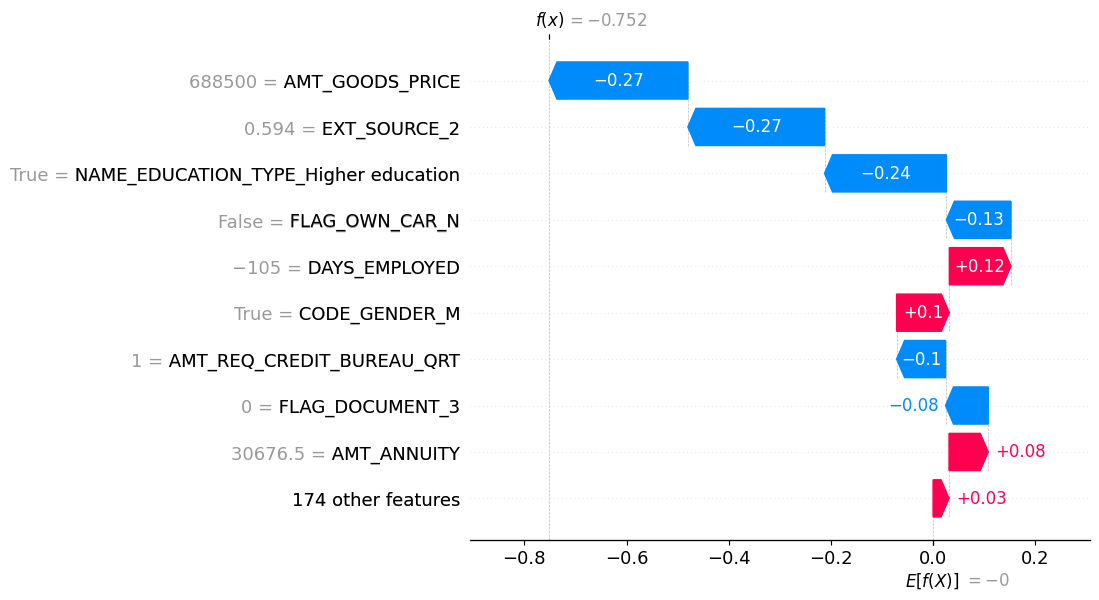

In [55]:
# Explain applicant at index 0
shap.plots.waterfall(shap_values[0])

In [56]:
import numpy as np

def get_top_features(shap_values, feature_names, applicant_index, n=3):
    vals = shap_values.values[applicant_index]
    top_indices = np.argsort(np.abs(vals))[::-1][:n]
    return [(feature_names[i], round(vals[i], 4)) for i in top_indices]

feature_names = X_test.columns.tolist()
top_3 = get_top_features(shap_values, feature_names, applicant_index=0, n=3)

print("Top 3 features for applicant 0:")
for feature, value in top_3:
    direction = "increases" if value > 0 else "decreases"
    print(f"  {feature}: {value} ({direction} default probability)")

Top 3 features for applicant 0:
  AMT_GOODS_PRICE: -0.2718000113964081 (decreases default probability)
  EXT_SOURCE_2: -0.26739999651908875 (decreases default probability)
  NAME_EDUCATION_TYPE_Higher education: -0.23849999904632568 (decreases default probability)


# 8: [not used] Explanation Template (early draft, superseded by Section 10)

*This was the first draft of the explanation generator, before the SCENARIO_FIXED filtering, deduplication, and feature-specific descriptions were added. Kept here as a record of the process, the working version is Section 10, cell 9 (`generate_explanation`).*

In [57]:
def generate_explanation(top_features, literacy_level):
    feature_name, shap_value = top_features[0]
    direction = "increases" if shap_value > 0 else "decreases"
    direction_plain = "flagged" if shap_value > 0 else "helped"

    if literacy_level == "low":
        return (
            f"The main reason your application was reviewed carefully is your {feature_name.lower().replace('_', ' ')}. "
            f"This is the factor that most {direction_plain} your application."
        )
    elif literacy_level == "medium":
        return (
            f"Your {feature_name.lower().replace('_', ' ')} was the primary factor affecting your credit assessment. "
            f"It {direction} the likelihood of default in your profile."
        )
    elif literacy_level == "high":
        return (
            f"The dominant feature in your credit assessment was {feature_name} "
            f"(SHAP contribution: {shap_value}), which {direction} your predicted default probability "
            f"relative to the baseline."
        )
    elif literacy_level == "standard":
        return (
            "Your application was assessed based on your financial history, income, and credit profile. "
            "Several factors were considered in this decision."
        )

# Example usage
top_3 = get_top_features(shap_values, feature_names, applicant_index=0, n=3)

for level in ["low", "medium", "high", "standard"]:
    print(f"\n[{level.upper()}]")
    print(generate_explanation(top_3, level))


[LOW]
The main reason your application was reviewed carefully is your amt goods price. This is the factor that most helped your application.

[MEDIUM]
Your amt goods price was the primary factor affecting your credit assessment. It decreases the likelihood of default in your profile.

[HIGH]
The dominant feature in your credit assessment was AMT_GOODS_PRICE (SHAP contribution: -0.2718000113964081), which decreases your predicted default probability relative to the baseline.

[STANDARD]
Your application was assessed based on your financial history, income, and credit profile. Several factors were considered in this decision.


In [58]:
import numpy as np

feature_names = X_test.columns.tolist()

# Find EXT_SOURCE_2 index
ext2_idx = feature_names.index('EXT_SOURCE_2')

# Get its SHAP value for applicant 0
ext2_shap = shap_values.values[0][ext2_idx]
print(f"EXT_SOURCE_2 SHAP for applicant 0: {ext2_shap:.4f}")

# Get mean absolute SHAP across all test set applicants (more representative)
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_features = sorted(zip(feature_names, mean_abs_shap), key=lambda x: x[1], reverse=True)[:20]

print("\nTop 20 features by mean absolute SHAP (across all applicants):")
for feat, val in top_features:
    print(f"  {feat}: {val:.4f}")

EXT_SOURCE_2 SHAP for applicant 0: -0.2674

Top 20 features by mean absolute SHAP (across all applicants):
  EXT_SOURCE_3: 0.3737
  EXT_SOURCE_2: 0.3544
  AMT_GOODS_PRICE: 0.1465
  DAYS_EMPLOYED: 0.1011
  AMT_CREDIT: 0.1001
  DAYS_BIRTH: 0.0982
  NAME_EDUCATION_TYPE_Higher education: 0.0943
  FLAG_OWN_CAR_N: 0.0804
  CODE_GENDER_M: 0.0770
  AMT_ANNUITY: 0.0657
  CODE_GENDER_F: 0.0616
  DAYS_ID_PUBLISH: 0.0493
  NAME_FAMILY_STATUS_Married: 0.0472
  NAME_CONTRACT_TYPE_Cash loans: 0.0457
  FLAG_DOCUMENT_3: 0.0451
  NAME_INCOME_TYPE_Working: 0.0366
  DAYS_LAST_PHONE_CHANGE: 0.0347
  REGION_RATING_CLIENT_W_CITY: 0.0341
  AMT_REQ_CREDIT_BUREAU_QRT: 0.0251
  NAME_EDUCATION_TYPE_Secondary / secondary special: 0.0246


---

# 9: Balanced Sampling for Phase 2

In [59]:
from sklearn.utils import resample
import pandas as pd

# Count how many defaulters are in the test set
n_minority = (y_test == 1).sum()
print("Total defaulters available:", n_minority)

# Split test set into defaulters and non-defaulters
X_test_1 = X_test[y_test == 1]
X_test_0 = X_test[y_test == 0]
y_test_1 = y_test[y_test == 1]
y_test_0 = y_test[y_test == 0]

# Randomly sample non-defaulters to match the defaulter count
X_test_0s = resample(X_test_0, n_samples=n_minority, random_state=42)
y_test_0s = resample(y_test_0, n_samples=n_minority, random_state=42)

# Combine into the balanced set
X_test_balanced = pd.concat([X_test_1, X_test_0s])
y_test_balanced = pd.concat([y_test_1, y_test_0s])

print("Balanced sample shape:", X_test_balanced.shape)
print(y_test_balanced.value_counts())

Total defaulters available: 4965
Balanced sample shape: (9930, 183)
TARGET
1    4965
0    4965
Name: count, dtype: int64


`n_minority = (y_test == 1).sum()` counts how many defaulters exist in the test set.

The next four lines split the test set into two piles: **defaulters** and **non-defaulters**, each with their matching X (features) and y (labels) kept together.

`resample(X_test_0, n_samples=n_minority, random_state=42)` takes the big pile of non-defaulters (56,538) and **randomly picks** exactly 4,965 of them. `random_state=42` means it picks the same 4,965 every time you run this, so your results are reproducible.



**// how can the number 42 does this? why is it so significant??? wait, did i just stumble upon the answer to the life, the universe & everything?? O_O!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa**

### Re-running balanced sample

In [60]:
import shap

explainer = shap.TreeExplainer(model)
shap_values_balanced = explainer(X_test_balanced)

print("SHAP values shape:", shap_values_balanced.values.shape)

SHAP values shape: (9930, 183)


# 10: Modified to Indonesia's context

### 1- Building the "default applicant" template

In [61]:
# --- Building the "default applicant" template ---
# This is a single row with all 183 columns, filled with the median value from the training data for each column.

default_applicant = X_train.median()

print("Default applicant template created.")
print("Total columns:", len(default_applicant))
print("\nExample values:")
print("  AMT_INCOME_TOTAL:", default_applicant['AMT_INCOME_TOTAL'])
print("  EXT_SOURCE_2:", default_applicant['EXT_SOURCE_2'])
print("  EXT_SOURCE_3:", default_applicant['EXT_SOURCE_3'])

Default applicant template created.
Total columns: 183

Example values:
  AMT_INCOME_TOTAL: 147600.0
  EXT_SOURCE_2: 0.5659614260608526
  EXT_SOURCE_3: 0.5352762504724826


### 2- build_applicant_row function

In [62]:
# --- Building a single participant's row ---
#
# Takes a dictionary of answers from the Phase 2 form and returns a full 183-column row ready for the model.
#
# Strategy: start with the default_applicant (all 183 columns filled with typical values), then overwrite only the columns this specific participant answered. Everything else stays at the median/mode value.

def build_applicant_row(answers, default_applicant, feature_names):
    row = default_applicant.copy()

    # --- 1. Simple numeric answers ---
    # The model stores age and employment length as NEGATIVE days (e.g. -12775 days = 35 years old). Participants give us years, so we convert: years * 365, then make it negative.

    row['DAYS_BIRTH'] = -answers['age_years'] * 365
    row['DAYS_EMPLOYED'] = -answers['years_employed'] * 365

    # AMT_INCOME_TOTAL in the dataset is ANNUAL income.
    # Our form asks for MONTHLY income, so we multiply by 12.
    # *** This is a common spot for a silent logic error -- if the form
    # later changes to ask for annual income directly, this line must
    # be updated or incomes will be 12x too high. ***
    row['AMT_INCOME_TOTAL'] = answers['monthly_income'] * 12

    row['CNT_FAM_MEMBERS'] = answers['family_members']

    # --- 2. Yes/No questions (own car, own property) ---
    # These were one-hot encoded into _Y and _N columns during training.
    # For each one: set both to 0 first, then set the correct one to 1.

    yes_no_map = {
        'FLAG_OWN_CAR': 'own_car',
        'FLAG_OWN_REALTY': 'own_realty',
    }

    for base_col, answer_key in yes_no_map.items():
        for suffix in ['_Y', '_N']:
            col = base_col + suffix
            if col in feature_names:
                row[col] = 0
        chosen = base_col + ('_Y' if answers[answer_key] == 'Yes' else '_N')
        if chosen in feature_names:
            row[chosen] = 1

    # --- 3. Multiple-choice questions (gender, education, etc.) ---
    # Each of these became MULTIPLE columns during training, one per
    # option (e.g. NAME_EDUCATION_TYPE_Higher education,
    # NAME_EDUCATION_TYPE_Secondary, etc., each 0 or 1).
    #
    # For each one: find ALL its columns, set them all to 0, then set
    # the participant's chosen option to 1.
    #
    # *** IMPORTANT: the value in 'answers' must match the EXACT text
    # used in training (e.g. "Higher education", capitalised exactly
    # like this). A mismatch here will NOT throw an error -- the column
    # just won't be found, and that feature silently stays at its
    # default value. This is the "silent logic error" type to watch for. ***

    categorical_map = {
        'CODE_GENDER': 'gender',
        'NAME_EDUCATION_TYPE': 'education',
        'NAME_FAMILY_STATUS': 'marital_status',
        'NAME_INCOME_TYPE': 'employment_type',
        'OCCUPATION_TYPE': 'occupation',
        'NAME_HOUSING_TYPE': 'housing',
    }

    for base_col, answer_key in categorical_map.items():
        dummy_cols = [c for c in feature_names if c.startswith(base_col + '_')]
        for c in dummy_cols:
            row[c] = 0

        chosen_col = f"{base_col}_{answers[answer_key]}"
        if chosen_col in feature_names:
            row[chosen_col] = 1
        else:
            # !This print statement is the safety net -- if you see this
            # in the output, the answer text doesn't match the training data.
            print(f"WARNING: '{chosen_col}' not found in model columns. "
                  f"Check the exact spelling/capitalisation for '{answer_key}'.")

    # --- 4. The Q1 alternative question (EXT_SOURCE_2 and EXT_SOURCE_3) ---
    # Maps the late-payment answer to a numeric estimate

    if answers['late_payment'] == 'No':
        ext_value = 0.7
    elif answers['late_payment'] == 'Yes':
        ext_value = 0.3
    else:  # 'Not sure'
        ext_value = 0.51

    row['EXT_SOURCE_2'] = ext_value
    row['EXT_SOURCE_3'] = ext_value
    # Note: EXT_SOURCE_1 stays at its median value (default_applicant's value) -- it is not covered by the alternative question.

    # --- 5. Scenario-fixed values (same for every participant) ---

    for c in feature_names:
        if c.startswith('NAME_CONTRACT_TYPE_'):
            row[c] = 0
    if 'NAME_CONTRACT_TYPE_Cash loans' in feature_names:
        row['NAME_CONTRACT_TYPE_Cash loans'] = 1

    row['AMT_CREDIT'] = 30000000  # Rp 30,000,000 fixed loan amount

    # Underneath is the 1st bug!!!! :D
    row['AMT_GOODS_PRICE'] = 30000000  # match AMT_CREDIT
    # For a cash loan, AMT_CREDIT and AMT_GOODS_PRICE represent the same thing.
    # Leaving AMT_GOODS_PRICE at its training median (much higher than 5,000,000)
    # while AMT_CREDIT was fixed created an artificial "mismatch" that the model
    # read as risky for every profile -- not a real signal about the participant.

    return row


print("build_applicant_row function defined.")

build_applicant_row function defined.


### 3- Feature translation table

In [63]:
# --- Feature name translation table ---
#
# Maps raw model column names to plain language.
# Used as fallback in get_specific_description below.
#
# *** DRAFT -- revise after Phase 1 thematic analysis ***

FEATURE_TRANSLATIONS = {
    'EXT_SOURCE_2': {
        'label':    'riwayat pembayaran / payment history',
        'positive': 'your payment history raised concerns',
        'negative': 'your payment history showed no issues',
    },
    'EXT_SOURCE_3': {
        'label':    'riwayat pembayaran / payment history',
        'positive': 'your payment history raised concerns',
        'negative': 'your payment history showed no issues',
    },
    'DAYS_EMPLOYED': {
        'label':    'lama bekerja / employment length',
        'positive': 'your short time in your current job raised concerns',
        'negative': 'your stable employment history worked in your favour',
    },
    'DAYS_BIRTH': {
        'label':    'usia / age',
        'positive': 'your age was flagged as a factor',
        'negative': 'your age worked in your favour',
    },
    'FLAG_OWN_CAR_N': {
        'label':    'kepemilikan kendaraan / vehicle ownership',
        'positive': 'not owning a vehicle was noted',
        'negative': 'not owning a vehicle was not a concern',
    },
    'FLAG_OWN_CAR_Y': {
        'label':    'kepemilikan kendaraan / vehicle ownership',
        'positive': 'owning a vehicle was flagged',
        'negative': 'owning a vehicle worked in your favour',
    },
    'FLAG_OWN_REALTY_N': {
        'label':    'kepemilikan properti / property ownership',
        'positive': 'not owning property was noted as a concern',
        'negative': 'not owning property was not a concern',
    },
    'FLAG_OWN_REALTY_Y': {
        'label':    'kepemilikan properti / property ownership',
        'positive': 'owning property was flagged',
        'negative': 'owning property worked in your favour',
    },
    'NAME_EDUCATION_TYPE_Higher education': {
        'label':    'pendidikan / education level',
        'positive': 'your education level raised concerns',
        'negative': 'your education background worked in your favour',
    },
    'NAME_EDUCATION_TYPE_Secondary / secondary special': {
        'label':    'pendidikan / education level',
        'positive': 'your education level raised concerns',
        'negative': 'your education level was considered',
    },
    'NAME_EDUCATION_TYPE_Incomplete higher': {
        'label':    'pendidikan / education level',
        'positive': 'your education level raised concerns',
        'negative': 'your education level was considered',
    },
    'NAME_EDUCATION_TYPE_Lower secondary': {
        'label':    'pendidikan / education level',
        'positive': 'your education level raised concerns',
        'negative': 'your education level was considered',
    },
    'NAME_EDUCATION_TYPE_Academic degree': {
        'label':    'pendidikan / education level',
        'positive': 'your education level raised concerns',
        'negative': 'your academic background worked in your favour',
    },
    'OCCUPATION_TYPE_Low-skill Laborers': {
        'label':    'jenis pekerjaan / occupation type',
        'positive': 'your occupation type raised concerns',
        'negative': 'your occupation type was considered',
    },
    'OCCUPATION_TYPE_Laborers': {
        'label':    'jenis pekerjaan / occupation type',
        'positive': 'your occupation type raised concerns',
        'negative': 'your occupation type was considered',
    },
    'OCCUPATION_TYPE_Core staff': {
        'label':    'jenis pekerjaan / occupation type',
        'positive': 'your occupation type raised concerns',
        'negative': 'your work role worked in your favour',
    },
    'OCCUPATION_TYPE_Managers': {
        'label':    'jenis pekerjaan / occupation type',
        'positive': 'your occupation type raised concerns',
        'negative': 'your management role worked in your favour',
    },
    'OCCUPATION_TYPE_Sales staff': {
        'label':    'jenis pekerjaan / occupation type',
        'positive': 'your occupation type raised concerns',
        'negative': 'your occupation type was considered',
    },
    'NAME_INCOME_TYPE_Working': {
        'label':    'status pekerjaan / employment status',
        'positive': 'your employment status raised concerns',
        'negative': 'your employment status worked in your favour',
    },
    'NAME_INCOME_TYPE_Commercial associate': {
        'label':    'status pekerjaan / employment status',
        'positive': 'your employment status raised concerns',
        'negative': 'your employment status worked in your favour',
    },
    'NAME_INCOME_TYPE_Pensioner': {
        'label':    'status pekerjaan / employment status',
        'positive': 'your pensioner status raised concerns',
        'negative': 'your pensioner status was considered',
    },
    'NAME_INCOME_TYPE_State servant': {
        'label':    'status pekerjaan / employment status',
        'positive': 'your employment status raised concerns',
        'negative': 'your civil servant status worked in your favour',
    },
    'CNT_FAM_MEMBERS': {
        'label':    'jumlah anggota keluarga / family size',
        'positive': 'your family size raised concerns',
        'negative': 'your family size was not a concern',
    },
    'NAME_HOUSING_TYPE_House / apartment': {
        'label':    'status tempat tinggal / housing situation',
        'positive': 'your housing situation raised concerns',
        'negative': 'your housing situation worked in your favour',
    },
    'NAME_HOUSING_TYPE_Rented apartment': {
        'label':    'status tempat tinggal / housing situation',
        'positive': 'renting your home was noted as a concern',
        'negative': 'your housing situation was not a concern',
    },
    'NAME_HOUSING_TYPE_With parents': {
        'label':    'status tempat tinggal / housing situation',
        'positive': 'living with family was noted as a concern',
        'negative': 'your housing situation was not a concern',
    },
    'NAME_FAMILY_STATUS_Married': {
        'label':    'status pernikahan / marital status',
        'positive': 'your marital status raised concerns',
        'negative': 'being married worked in your favour',
    },
    'NAME_FAMILY_STATUS_Single / not married': {
        'label':    'status pernikahan / marital status',
        'positive': 'your marital status raised concerns',
        'negative': 'your marital status was not a concern',
    },
}

def get_feature_text(feature_name, shap_value):
    direction = 'positive' if shap_value > 0 else 'negative'
    if feature_name in FEATURE_TRANSLATIONS:
        return FEATURE_TRANSLATIONS[feature_name][direction]
    else:
        print(f"MISSING TRANSLATION: {feature_name} -- add to FEATURE_TRANSLATIONS")
        return "a factor in your profile was considered"

print("Feature translation table loaded.")
print(f"Total features covered: {len(FEATURE_TRANSLATIONS)}")

Feature translation table loaded.
Total features covered: 28


### 4- explain_applicant function

In [64]:
# --- Run the model and SHAP for ONE participant ---

import numpy as np

feature_names = X_train.columns.tolist()

def explain_applicant(answers, model, explainer, default_applicant, feature_names, n_top=3):

    # Step 1: build their 183-column row
    row = build_applicant_row(answers, default_applicant, feature_names)
    row_df = pd.DataFrame([row], columns=feature_names)

    # Step 2: prediction
    default_probability = model.predict_proba(row_df)[0, 1]

    # Step 3: SHAP values for this one person
    shap_values_single = explainer(row_df)

    # Step 4: find top N features
    #
    # Three things filtered out before selecting top features:
    #
    # a) SCENARIO_FIXED -- same for every participant, can't explain
    #    why THIS person's result differs from anyone else's
    #
    # b) CODE_GENDER -- protected characteristic, excluded from
    #    participant-facing explanations (model still uses it internally)
    #
    # c) DUPLICATES BY LABEL -- EXT_SOURCE_2 and EXT_SOURCE_3 both map
    #    to "payment history". Showing both repeats the same reason twice.
    #    Keep only the one with higher absolute SHAP value (comes first
    #    since we sort by |SHAP|), skip the rest with the same label.

    SCENARIO_FIXED = {'AMT_CREDIT', 'AMT_GOODS_PRICE'}
    SCENARIO_FIXED |= {c for c in feature_names if c.startswith('NAME_CONTRACT_TYPE_')}
    SCENARIO_FIXED |= {c for c in feature_names if c.startswith('CODE_GENDER_')}

    vals = shap_values_single.values[0]
    sorted_indices = np.argsort(np.abs(vals))[::-1]

    seen_labels = set()
    top_indices = []

    for i in sorted_indices:
        feat = feature_names[i]
        if feat in SCENARIO_FIXED:
            continue
        # Get this feature's plain-language label for deduplication
        label = FEATURE_TRANSLATIONS.get(feat, {}).get('label', feat)
        if label not in seen_labels:
            seen_labels.add(label)
            top_indices.append(i)
        if len(top_indices) == n_top:
            break

    top_features = [(feature_names[i], round(float(vals[i]), 4)) for i in top_indices]

    return {
        'default_probability': round(float(default_probability), 4),
        'top_features': top_features
    }

print("explain_applicant function defined.")

explain_applicant function defined.


### 5- [experiment] Test - lower risk profile (Test 1)

In [65]:
# --- Test 1: a fake "lower risk" profile ---

test_answers_good = {
    'age_years': 40,
    'years_employed': 10,
    'monthly_income': 10000000,   # Rp 10,000,000/month
    'family_members': 2,
    'own_car': 'Yes',
    'own_realty': 'Yes',
    'gender': 'F',
    'education': 'Higher education',
    'marital_status': 'Married',
    'employment_type': 'Working',
    'occupation': 'Core staff',
    'housing': 'House / apartment',
    'late_payment': 'No',
}

result_good = explain_applicant(test_answers_good, model, explainer, default_applicant, feature_names)

print("=== LOWER RISK PROFILE ===")
print("Default probability:", result_good['default_probability'])
print("Top features:")
for feat, val in result_good['top_features']:
    direction = "increases" if val > 0 else "decreases"
    print(f"  {feat}: {val} ({direction} default probability)")

=== LOWER RISK PROFILE ===
Default probability: 0.1126
Top features:
  EXT_SOURCE_3: -0.6889 (decreases default probability)
  NAME_EDUCATION_TYPE_Higher education: -0.2512 (decreases default probability)
  DAYS_EMPLOYED: -0.1639 (decreases default probability)


### 6- [experiment] Test 2-5 (BEST/GOOD/RISKY/WORST) + bug notes

In [66]:
# --- Test 2-5: Spectrum from best to worst ---
#
# Compare these against Test 1 (default_probability = 0.1577) to check
# the model moves in sensible directions as the "story" gets worse.
#
# Expected rough order, best to worst:
#   BEST  -- higher income, higher education, "No" late payment
#   GOOD  -- similar to Test 1, moderate income, "No" late payment
#   RISKY -- young, low income, "Not sure" on late payment (median EXT_SOURCE)
#   WORST -- young, lowest income, "Yes" late payment (worst EXT_SOURCE)

test_profiles = {

    # BEST: high earner, owns assets, highly educated, clean payment history
    "BEST": {
        'age_years': 45,
        'years_employed': 15,
        'monthly_income': 20000000,   # Rp 20,000,000/month
        'family_members': 2,
        'own_car': 'Yes',
        'own_realty': 'Yes',
        'gender': 'F',
        'education': 'Academic degree',
        'marital_status': 'Married',
        'employment_type': 'Commercial associate',
        'occupation': 'Managers',
        'housing': 'House / apartment',
        'late_payment': 'No',
    },

    # GOOD: moderate income, similar shape to Test 1 but different details
    "GOOD": {
        'age_years': 35,
        'years_employed': 5,
        'monthly_income': 8000000,    # Rp 8,000,000/month
        'family_members': 3,
        'own_car': 'No',
        'own_realty': 'Yes',
        'gender': 'M',
        'education': 'Secondary / secondary special',
        'marital_status': 'Married',
        'employment_type': 'Working',
        'occupation': 'Sales staff',
        'housing': 'House / apartment',
        'late_payment': 'No',
    },

    # RISKY: young, low income, unsure about payment history
    # ("Not sure" -> EXT_SOURCE = 0.51, the median -- neutral, not bad)
    "RISKY": {
        'age_years': 24,
        'years_employed': 1,
        'monthly_income': 3000000,    # Rp 3,000,000/month
        'family_members': 4,
        'own_car': 'No',
        'own_realty': 'No',
        'gender': 'M',
        'education': 'Secondary / secondary special',
        'marital_status': 'Single / not married',
        'employment_type': 'Working',
        'occupation': 'Laborers',
        'housing': 'Rented apartment',
        'late_payment': 'Not sure',
    },

    # WORST: young, lowest income, least education, late payment = Yes
    # ("Yes" -> EXT_SOURCE = 0.3 -- the worst-direction value)
    "WORST": {
        'age_years': 21,
        'years_employed': 0,
        'monthly_income': 2000000,    # Rp 2,000,000/month
        'family_members': 5,
        'own_car': 'No',
        'own_realty': 'No',
        'gender': 'M',
        'education': 'Lower secondary',
        'marital_status': 'Single / not married',
        'employment_type': 'Working',
        'occupation': 'Low-skill Laborers',
        'housing': 'Rented apartment',
        'late_payment': 'Yes',
    },
}

# Run all four and print results
for label, answers in test_profiles.items():
    result = explain_applicant(answers, model, explainer, default_applicant, feature_names)
    print(f"=== {label} ===")
    print("Default probability:", result['default_probability'])
    print("Top features:")
    for feat, val in result['top_features']:
        direction = "increases" if val > 0 else "decreases"
        print(f"  {feat}: {val} ({direction} default probability)")
    print()

=== BEST ===
Default probability: 0.1298
Top features:
  EXT_SOURCE_3: -0.7046 (decreases default probability)
  DAYS_EMPLOYED: -0.2436 (decreases default probability)
  FLAG_OWN_CAR_N: -0.1623 (decreases default probability)

=== GOOD ===
Default probability: 0.2677
Top features:
  EXT_SOURCE_3: -0.5991 (decreases default probability)
  DAYS_BIRTH: 0.0896 (increases default probability)
  FLAG_OWN_CAR_N: 0.0781 (increases default probability)

=== RISKY ===
Default probability: 0.5706
Top features:
  DAYS_EMPLOYED: 0.0894 (increases default probability)
  FLAG_OWN_CAR_N: 0.0774 (increases default probability)
  NAME_EDUCATION_TYPE_Higher education: 0.0592 (increases default probability)

=== WORST ===
Default probability: 0.683
Top features:
  EXT_SOURCE_2: 0.3575 (increases default probability)
  OCCUPATION_TYPE_Low-skill Laborers: 0.1087 (increases default probability)
  DAYS_BIRTH: -0.0763 (decreases default probability)



#### 1st Bug found: `AMT_GOODS_PRICE` mismatch
When building the four test profiles (BEST/GOOD/RISKY/WORST), `AMT_GOODS_PRICE` appeared as a risk-increasing feature for GOOD, RISKY, and WORST -- regardless of how different those profiles were from each other. A feature that shows up the same way across completely different people is a red flag.

```
=== BEST ===
Default probability: 0.1816
Top features:
  EXT_SOURCE_3: -0.7772 (decreases default probability)
  EXT_SOURCE_2: -0.4756 (decreases default probability)
  DAYS_EMPLOYED: -0.2286 (decreases default probability)

=== GOOD ===
Default probability: 0.3661
Top features:
  EXT_SOURCE_3: -0.6718 (decreases default probability)
  EXT_SOURCE_2: -0.5699 (decreases default probability)
  AMT_GOODS_PRICE: 0.1318 (increases default probability)

=== RISKY ===
Default probability: 0.6804
Top features:
  AMT_GOODS_PRICE: 0.1496 (increases default probability)
  DAYS_BIRTH: -0.1073 (decreases default probability)
  AMT_CREDIT: 0.0992 (increases default probability)

=== WORST ===
Default probability: 0.7801
Top features:
  EXT_SOURCE_3: 0.3321 (increases default probability)
  EXT_SOURCE_2: 0.317 (increases default probability)
  AMT_GOODS_PRICE: 0.1517 (increases default probability)
```

* Cause: `AMT_CREDIT` was fixed at 5,000,000 (the scenario loan amount), but `AMT_GOODS_PRICE` was left at its training median, which is much higher. For a cash loan, these two values represent essentially the same thing, so this mismatch created an unrealistic combination. The model had learned that "loan amount far below goods price" is unusual, and flagged it as risky -- for every participant, independent of their actual answers.

* Why it wasn't caught immediately: the code ran without errors. The probabilities still produced a sensible best-to-worst gradient, so at a glance everything looked fine. The issue only became visible by comparing the top features across multiple different profiles and noticing the same irrelevant feature repeating.

* Fix: set `AMT_GOODS_PRICE = AMT_CREDIT` alongside the existing scenario-fixed value, so both reflect the same loan amount.

* Note: when fixing a scenario value, check if any other column is mathematically or conceptually related to it. A single fixed value in isolation can create an inconsistency the model reacts to. This is the kind of bug that produces plausible-looking but subtly wrong output.

#### 2nd bug > (found right after fixing bug 1)

After fixing `AMT_GOODS_PRICE = AMT_CREDIT`, the `AMT_GOODS_PRICE` was still showing up in the top 3 for almost every profile with basically the same value every time (~-0.26 to -0.27).

* Why it happened: `AMT_CREDIT` and `AMT_GOODS_PRICE` are FIXED for every participant (same loan amount) -> the model still uses them in the prediction, but they shouldn't show up in the explanation bc they can't explain why YOUR result is different from anyone else's

* Fix: added a `SCENARIO_FIXED` exclusion set in `explain_applicant()`. These columns are still used for the prediction, just filtered out before we pick the "top features" to show in the explanation. The same logic later applied to `CODE_GENDER` too (different reason: protected characteristic, shouldn't bevisible in explanations even if the model uses it.

* Notes: when fixing a silent bug, check if the same class of problem exists elsewhere. bug 1 and bug 2 are cousins?? both are about scenario-fixed values affecting participant-specific explanations

### 7- Benchmarks

In [67]:
# --- Benchmarks from training data ---
#
# Typical values from applicants who were approved (y_train == 0).
# Used in explanations to give context:
# e.g. "your income is below the typical level seen in approved applications"
#
# Not hard rules -- the model doesn't have explicit thresholds.
# These are approximate reference points only.

approved = X_train[y_train == 0]

BENCHMARKS = {
    'median_monthly_income': round(approved['AMT_INCOME_TOTAL'].median() / 12 / 500000) * 500000,
    'median_years_employed': round(abs(approved['DAYS_EMPLOYED'].median()) / 365, 1),
    'median_age': round(abs(approved['DAYS_BIRTH'].median()) / 365),
    'loan_amount': 10000000,
}

print("Benchmarks (from approved applicants in training data):")
for k, v in BENCHMARKS.items():
    print(f"  {k}: {v:,}")

Benchmarks (from approved applicants in training data):
  median_monthly_income: 0
  median_years_employed: 3.4
  median_age: 43
  loan_amount: 10,000,000


### 8- Specific description function

In [68]:
# --- Specific description generator ---
#
# Returns a participant-specific sentence using their actual answers.
# More meaningful than generic text like "raised concerns."
# Falls back to FEATURE_TRANSLATIONS if feature not covered here.

def get_specific_description(feature_name, shap_value, answers):
    is_concern = shap_value > 0

    if feature_name in ['EXT_SOURCE_2', 'EXT_SOURCE_3']:
        if answers['late_payment'] == 'Yes':
            return "you indicated having had previous late payments"
        elif answers['late_payment'] == 'No':
            return "your payment history showed no previous late payments"
        else:
            return "your payment history could not be fully confirmed"

    if feature_name == 'DAYS_EMPLOYED':
        years = answers['years_employed']
        benchmark = BENCHMARKS['median_years_employed']
        if is_concern:
            return (f"your current employment of {years} year(s) is below "
                    f"the typical {benchmark:.0f}+ years seen in approved "
                    f"applications for this loan amount")
        else:
            return f"your {years} years of stable employment supported your application"

    if feature_name == 'DAYS_BIRTH':
        age = answers['age_years']
        if is_concern:
            return f"your age of {age} was flagged as a factor for this loan type"
        else:
            return f"your age of {age} was in line with typical approved applicants"

    if feature_name == 'FLAG_OWN_CAR_N':
        if is_concern:
            return ("not owning a vehicle was noted -- "
                    "applicants with assets tend to have stronger profiles")
        else:
            return "not owning a vehicle was not a significant factor"

    if feature_name == 'FLAG_OWN_CAR_Y':
        if is_concern:
            return "owning a vehicle was not a deciding factor"
        else:
            return "owning a vehicle indicated asset ownership, which supported your application"

    if feature_name == 'FLAG_OWN_REALTY_N':
        if is_concern:
            return ("not owning property was noted -- "
                    "property ownership can indicate financial stability")
        else:
            return "not owning property was not a significant concern"

    if feature_name == 'FLAG_OWN_REALTY_Y':
        if is_concern:
            return "owning property was noted but was not the deciding factor"
        else:
            return "owning property indicated financial stability"

    if feature_name.startswith('OCCUPATION_TYPE_'):
        occupation = answers['occupation']
        if is_concern:
            return (f"your occupation as {occupation.lower()} "
                    f"raised concerns for a loan of Rp {BENCHMARKS['loan_amount']:,}")
        else:
            return f"your occupation as {occupation.lower()} was considered positively"

    if feature_name.startswith('NAME_EDUCATION_TYPE_'):
        education = answers['education']
        if is_concern:
            return f"your education level ({education.lower()}) was flagged as a factor"
        else:
            return f"your education level ({education.lower()}) supported your application"

    if feature_name.startswith('NAME_HOUSING_TYPE_'):
        housing = answers['housing']
        if is_concern:
            return f"your housing situation ({housing.lower()}) raised some concerns"
        else:
            return f"your housing situation ({housing.lower()}) was not a concern"

    if feature_name == 'CNT_FAM_MEMBERS':
        members = int(answers['family_members'])
        if is_concern:
            return (f"having {members} family member(s) raised concerns "
                    f"about repayment capacity for this loan amount")
        else:
            return f"your family size was not a significant concern"

    if feature_name.startswith('NAME_INCOME_TYPE_'):
        emp_type = answers['employment_type']
        if is_concern:
            return f"your employment type ({emp_type.lower()}) raised concerns"
        else:
            return f"your employment type ({emp_type.lower()}) was noted positively"

    if feature_name.startswith('NAME_FAMILY_STATUS_'):
        status = answers['marital_status']
        if is_concern:
            return f"your marital status ({status.lower()}) was flagged as a factor"
        else:
            return f"your marital status ({status.lower()}) was not a concern"

    # Fallback to FEATURE_TRANSLATIONS
    print(f"MISSING SPECIFIC DESCRIPTION: {feature_name} -- add to get_specific_description()")
    direction = 'positive' if is_concern else 'negative'
    return FEATURE_TRANSLATIONS.get(feature_name, {}).get(direction, "a factor in your profile was noted")

print("get_specific_description function defined.")

get_specific_description function defined.


### 9- generate_explanation (new version)

In [69]:
# --- Explanation template generator v2 ---
#
# Updated to take answers so templates reference participant's actual values.
#
# Literacy levels:
#   low      → plain language, Bahasa Indonesia, minimal numbers
#   medium   → simple terms, some numbers, EN/ID mixed
#   high     → technical terms, SHAP values shown
#   standard → generic, same for everyone (control condition)
#
# *** DRAFT -- revise after Phase 1 thematic analysis ***
#
# NOTE: 'outcome' was originally built to support both approved and rejected
# results. Phase 2 now uses a fixed scenario character that is always
# rejected (see Section 10e -- personalization dropped). The outcome-dependent
# lines below are disabled with '#' rather than deleted, so the original
# design is still visible. Each disabled line is followed by its simplified,
# always-rejected equivalent.

def generate_explanation(result, answers, literacy_level, outcome='rejected'):

    prob = result['default_probability']
    top_features = result['top_features']

    reasons = [
        get_specific_description(f, v, answers)
        for f, v in top_features
    ]

    # outcome_en = "was not approved" if outcome == 'rejected' else "was approved"  # DISABLED -- always rejected now
    outcome_en = "was not approved"

    income = answers['monthly_income']
    income_ratio = income / BENCHMARKS['loan_amount']
    income_is_low = income_ratio < 0.3

    # -------------------------------------------------------
    if literacy_level == 'low':
        text = "Your loan application was not approved.\n\n"
        text += f"Main reason: {reasons[0]}.\n"

        if len(reasons) > 1:
            shap_2 = top_features[1][1]
            # if shap_2 < 0 and outcome == 'rejected':  # DISABLED -- always rejected now
            if shap_2 < 0:
                text += (f"\nOn the positive side, {reasons[1]} -- "
                         f"but this wasn't enough to offset the main concerns.\n")
            else:
                text += f"\nAdditionally, {reasons[1]}.\n"

        if income_is_low:
            text += (f"\nYour monthly income of Rp {income:,.0f} may be "
                     f"considered low for a loan of "
                     f"Rp {BENCHMARKS['loan_amount']:,}.\n")

        text += "\nYou may reapply later or contact customer support for more information."

    # -------------------------------------------------------
    elif literacy_level == 'medium':
        text = "Your loan application was not approved.\n\n"
        text += f"The main factor: {reasons[0]}.\n"

        if len(reasons) > 1:
            shap_2 = top_features[1][1]
            # if shap_2 < 0 and outcome == 'rejected':  # DISABLED -- always rejected now
            if shap_2 < 0:
                text += (f"\nOn a positive note, {reasons[1]} -- "
                         f"however, this was outweighed by other factors.\n")
            else:
                text += f"\nAdditionally, {reasons[1]}.\n"

        if len(reasons) > 2:
            shap_3 = top_features[2][1]
            # if shap_3 < 0 and outcome == 'rejected':  # DISABLED -- always rejected now
            if shap_3 < 0:
                text += (f"We also noted that {reasons[2]} -- "
                         f"though this worked in your favour.\n")
            else:
                text += f"We also noted that {reasons[2]}.\n"

        if income_is_low:
            text += (f"\nYour monthly income of Rp {income:,.0f} is below "
                     f"the typical level expected for a loan of "
                     f"Rp {BENCHMARKS['loan_amount']:,}.\n")

        text += "\nThese factors were assessed based on the information you provided."

    # -------------------------------------------------------
    elif literacy_level == 'high':
        risk_label = "high" if prob > 0.6 else "moderate" if prob > 0.4 else "low"
        risk_pct = round(prob * 100, 1)
        text = (f"Your loan application {outcome_en}. "
                f"Your profile was assessed as {risk_label} risk "
                f"(default risk: {risk_pct}%).\n\n")
        text += "The following factors had the most impact on this decision:\n"

        for i, (feat, shap_val) in enumerate(top_features, 1):
            desc = get_specific_description(feat, shap_val, answers)
            direction = "increased" if shap_val > 0 else "reduced"
            note = ""
            # if shap_val < 0 and outcome == 'rejected':  # DISABLED -- always rejected now
            if shap_val < 0:
                note = " -- this worked in your favour but was outweighed by other factors"
            text += f"\n{i}. {desc[0].upper() + desc[1:]} ({direction} risk{note})"

        if income_is_low:
            text += (f"\n\nAdditionally, your monthly income of Rp {income:,.0f} "
                     f"is below the typical level expected for a loan of "
                     f"Rp {BENCHMARKS['loan_amount']:,}.")

    # -------------------------------------------------------
    elif literacy_level == 'standard':
        text = ("We are sorry. Your loan application was not approved.\n\n"
                "You may try again later or contact customer support for more information.")

    return text


print("generate_explanation (v2) defined.")


generate_explanation (v2) defined.


### 10- [experiment] Testing max restrain

#### 10a- [experiment] Test with WORST profile

In [70]:
# Test all four literacy levels using the WORST profile

result_worst = explain_applicant(
    test_profiles['WORST'],
    model, explainer,
    default_applicant,
    feature_names
)

print("Default probability:", result_worst['default_probability'])
print("=" * 60)

for level in ['low', 'medium', 'high', 'standard']:
    print(f"\n[{level.upper()}]")
    print("-" * 40)
    print(generate_explanation(result_worst, test_profiles['WORST'], level, outcome='rejected'))
    print()

Default probability: 0.683

[LOW]
----------------------------------------
Your loan application was not approved.

Main reason: you indicated having had previous late payments.

Additionally, your occupation as low-skill laborers raised concerns for a loan of Rp 10,000,000.

Your monthly income of Rp 2,000,000 may be considered low for a loan of Rp 10,000,000.

You may reapply later or contact customer support for more information.


[MEDIUM]
----------------------------------------
Your loan application was not approved.

The main factor: you indicated having had previous late payments.

Additionally, your occupation as low-skill laborers raised concerns for a loan of Rp 10,000,000.
We also noted that your age of 21 was in line with typical approved applicants -- though this worked in your favour.

Your monthly income of Rp 2,000,000 is below the typical level expected for a loan of Rp 10,000,000.

These factors were assessed based on the information you provided.


[HIGH]
----------

#### 10b- Various loan amount

In [71]:
# --- Test: loan amount sensitivity for realistic participant income ---
#
# Original BEST/GOOD profiles used income assumptions calibrated for
# UMR-level earners (Rp 8-20,000,000/month spread). Since participants
# are mostly middle workers earning >Rp 10,000,000/month, this test
# uses adjusted income values closer to the real population, and checks
# whether 10/20/35/50 million loan amounts are enough to push a strong
# profile toward rejection.

test_amounts = [10000000, 20000000, 35000000, 50000000]

# Adjusted profiles reflecting actual participant income range
realistic_profiles = {

    "BEST (realistic income)": {
        'age_years': 38,
        'years_employed': 10,
        'monthly_income': 18000000,   # Rp 18,000,000/month
        'family_members': 2,
        'own_car': 'Yes',
        'own_realty': 'Yes',
        'gender': 'F',
        'education': 'Academic degree',
        'marital_status': 'Married',
        'employment_type': 'Commercial associate',
        'occupation': 'Managers',
        'housing': 'House / apartment',
        'late_payment': 'No',
    },

    "GOOD (realistic income)": {
        'age_years': 32,
        'years_employed': 4,
        'monthly_income': 12000000,   # Rp 12,000,000/month
        'family_members': 3,
        'own_car': 'No',
        'own_realty': 'Yes',
        'gender': 'M',
        'education': 'Higher education',
        'marital_status': 'Married',
        'employment_type': 'Working',
        'occupation': 'Core staff',
        'housing': 'House / apartment',
        'late_payment': 'No',
    },
}

for label, answers in realistic_profiles.items():
    print(f"=== {label} ===")
    for amt in test_amounts:
        row = build_applicant_row(answers, default_applicant, feature_names)
        row['AMT_CREDIT'] = amt
        row['AMT_GOODS_PRICE'] = amt
        row_df = pd.DataFrame([row], columns=feature_names)
        prob = model.predict_proba(row_df)[0, 1]
        ratio = round(amt / answers['monthly_income'], 1)
        outcome = "REJECTED" if prob > 0.5 else "approved"
        print(f"  Loan Rp {amt:,} ({ratio}x income): probability = {round(prob, 4)} -> {outcome}")
    print()

=== BEST (realistic income) ===
  Loan Rp 10,000,000 (0.6x income): probability = 0.1615000069141388 -> approved
  Loan Rp 20,000,000 (1.1x income): probability = 0.1615000069141388 -> approved
  Loan Rp 35,000,000 (1.9x income): probability = 0.1615000069141388 -> approved
  Loan Rp 50,000,000 (2.8x income): probability = 0.1615000069141388 -> approved

=== GOOD (realistic income) ===
  Loan Rp 10,000,000 (0.8x income): probability = 0.19550000131130219 -> approved
  Loan Rp 20,000,000 (1.7x income): probability = 0.19550000131130219 -> approved
  Loan Rp 35,000,000 (2.9x income): probability = 0.19550000131130219 -> approved
  Loan Rp 50,000,000 (4.2x income): probability = 0.19550000131130219 -> approved



#### 10c- Extremely high loan request

In [72]:
# --- Test: does an extreme loan amount (100mio) finally move the needle? ---

test_amounts_extreme = [10000000, 35000000, 100000000, 300000000]

for label, answers in realistic_profiles.items():
    print(f"=== {label} ===")
    for amt in test_amounts_extreme:
        row = build_applicant_row(answers, default_applicant, feature_names)
        row['AMT_CREDIT'] = amt
        row['AMT_GOODS_PRICE'] = amt
        row_df = pd.DataFrame([row], columns=feature_names)
        prob = model.predict_proba(row_df)[0, 1]
        ratio = round(amt / answers['monthly_income'], 1)
        outcome = "REJECTED" if prob > 0.5 else "approved"
        print(f"  Loan Rp {amt:,} ({ratio}x income): probability = {round(prob, 6)} -> {outcome}")
    print()

=== BEST (realistic income) ===
  Loan Rp 10,000,000 (0.6x income): probability = 0.16145600378513336 -> approved
  Loan Rp 35,000,000 (1.9x income): probability = 0.16145600378513336 -> approved
  Loan Rp 100,000,000 (5.6x income): probability = 0.16145600378513336 -> approved
  Loan Rp 300,000,000 (16.7x income): probability = 0.16145600378513336 -> approved

=== GOOD (realistic income) ===
  Loan Rp 10,000,000 (0.8x income): probability = 0.1955070048570633 -> approved
  Loan Rp 35,000,000 (2.9x income): probability = 0.1955070048570633 -> approved
  Loan Rp 100,000,000 (8.3x income): probability = 0.1955070048570633 -> approved
  Loan Rp 300,000,000 (25.0x income): probability = 0.1955070048570633 -> approved



#### 10d- Low salary vs high loan request

In [73]:
# --- Test: lower income (4mio) + higher loan (50mio) ---
#
# Previous tests varied loan amount while holding income at 12-18mio (high).
# This test changes BOTH: income drops to 4mio (closer to entry-level/UMR),
# loan stays high at 50mio. Isolates whether income itself is the stronger
# lever, separate from loan amount.

test_profile_low_income = {
    'age_years': 28,
    'years_employed': 3,
    'monthly_income': 4000000,    # Rp 4,000,000/month
    'family_members': 2,
    'own_car': 'No',
    'own_realty': 'No',
    'gender': 'M',
    'education': 'Secondary / secondary special',
    'marital_status': 'Single / not married',
    'employment_type': 'Working',
    'occupation': 'Sales staff',
    'housing': 'Rented apartment',
    'late_payment': 'No',
}

row = build_applicant_row(test_profile_low_income, default_applicant, feature_names)
row['AMT_CREDIT'] = 50000000
row['AMT_GOODS_PRICE'] = 50000000
row_df = pd.DataFrame([row], columns=feature_names)
prob = model.predict_proba(row_df)[0, 1]
ratio = round(50000000 / 4000000, 1)
outcome = "REJECTED" if prob > 0.5 else "approved"

print(f"Income Rp 4,000,000, Loan Rp 50,000,000 ({ratio}x income)")
print(f"Probability: {round(prob, 4)} -> {outcome}")

# Also check top SHAP features to see what's actually driving this
result = explain_applicant(test_profile_low_income, model, explainer, default_applicant, feature_names)
print("\nTop features:")
for feat, val in result['top_features']:
    direction = "increases" if val > 0 else "decreases"
    print(f"  {feat}: {val} ({direction} default probability)")

Income Rp 4,000,000, Loan Rp 50,000,000 (12.5x income)
Probability: 0.3127000033855438 -> approved

Top features:
  EXT_SOURCE_3: -0.5941 (decreases default probability)
  NAME_FAMILY_STATUS_Married: 0.0987 (increases default probability)
  DAYS_EMPLOYED: 0.0827 (increases default probability)


#### 10e- Discarded personalization, fixed rejection

In [74]:
test_new_character = {
    'age_years': 26,
    'years_employed': 4,
    'monthly_income': 12000000,
    'family_members': 1,
    'own_car': 'No',
    'own_realty': 'No',
    'gender': 'M',
    'education': 'Higher education',   # or 'Academic degree' for closer S2 match
    'marital_status': 'Single / not married',
    'employment_type': 'Working',
    'occupation': 'Core staff',          # placeholder, fits S2 better than low-skill
    'housing': 'Rented apartment',     # nearest match to kos-kosan
    'late_payment': 'Yes',
}

result = explain_applicant(test_new_character, model, explainer, default_applicant, feature_names)
print("Default probability:", result['default_probability'])
print("Outcome:", "REJECTED" if result['default_probability'] > 0.5 else "approved")
print("\nTop features:")
for feat, val in result['top_features']:
    direction = "increases" if val > 0 else "decreases"
    print(f"  {feat}: {val} ({direction} default probability)")

Default probability: 0.6359
Outcome: REJECTED

Top features:
  EXT_SOURCE_2: 0.412 (increases default probability)
  NAME_EDUCATION_TYPE_Higher education: -0.1455 (decreases default probability)
  DAYS_BIRTH: -0.0834 (decreases default probability)


# 11: Locked scenario character

In [75]:
# --- LOCKED: Phase 2 fixed scenario character ---
#
# Single fixed applicant profile used for every Phase 2 participant.
# Every participant sees the same scenario, same rejection, same explanation.
#
# Why fixed: testing showed no realistic demographic combination reliably
# produces rejection -- EXT_SOURCE dominates the model so completely that
# late_payment = 'Yes' is the only lever that consistently flips the outcome.
# See Section 10 experiments for the full testing record.
#
# Why this profile:
#   - 26yo S1 grad, 4 years employed as Core staff
#   - Rp 12,000,000/month -- realistic for middle-income Jakarta workers
#   - Kos-kosan (rented apartment) -- common for this demographic
#   - late_payment = 'Yes' -- the essential lever, sets EXT_SOURCE_2/3 = 0.3
#
# Loan: Rp 30,000,000 chosen over 10,000,000 for realism -- 2.5x monthly
# income feels like a consequential request; model is unaffected by amount.
#
# Confirmed result: REJECTED (default probability ~0.63)
# Top SHAP features:
#   1. EXT_SOURCE_2: positive (late payment -- dominant driver)
#   2. NAME_EDUCATION_TYPE_Higher education: negative (works in favour, outweighed)
#   3. DAYS_BIRTH: negative (works in favour, outweighed)

SCENARIO_CHARACTER = {
    'age_years': 26,
    'years_employed': 4,
    'monthly_income': 12000000,       # Rp 12,000,000/month
    'family_members': 1,
    'own_car': 'No',
    'own_realty': 'No',
    'gender': 'M',
    'education': 'Higher education',  # S1
    'marital_status': 'Single / not married',
    'employment_type': 'Working',
    'occupation': 'Core staff',
    'housing': 'Rented apartment',    # nearest match to kos-kosan
    'late_payment': 'Yes',            # <- the essential lever
}

SCENARIO_LOAN = {
    'AMT_CREDIT': 30000000,           # Rp 30,000,000
    'AMT_GOODS_PRICE': 30000000,      # matched to AMT_CREDIT
    'NAME_CONTRACT_TYPE': 'Cash loans',
    'tenor_months': 3,                # displayed in UI, does not affect model
}

# Run canonical result
result_scenario = explain_applicant(
    SCENARIO_CHARACTER, model, explainer, default_applicant, feature_names
)

print('=== LOCKED SCENARIO CHARACTER ===')
print(f"Default probability: {result_scenario['default_probability']}")
print(f"Outcome: {'REJECTED' if result_scenario['default_probability'] > 0.5 else 'approved'}")
print('\nTop features:')
for feat, val in result_scenario['top_features']:
    direction = 'increases' if val > 0 else 'decreases'
    print(f'  {feat}: {val} ({direction} default probability)')

print('\n=== EXPLANATION OUTPUTS ===')
for level in ['low', 'medium', 'high', 'standard']:
    print(f'\n[{level.upper()}]')
    print('-' * 40)
    print(generate_explanation(result_scenario, SCENARIO_CHARACTER, level))


=== LOCKED SCENARIO CHARACTER ===
Default probability: 0.6359
Outcome: REJECTED

Top features:
  EXT_SOURCE_2: 0.412 (increases default probability)
  NAME_EDUCATION_TYPE_Higher education: -0.1455 (decreases default probability)
  DAYS_BIRTH: -0.0834 (decreases default probability)

=== EXPLANATION OUTPUTS ===

[LOW]
----------------------------------------
Your loan application was not approved.

Main reason: you indicated having had previous late payments.

On the positive side, your education level (higher education) supported your application -- but this wasn't enough to offset the main concerns.

You may reapply later or contact customer support for more information.

[MEDIUM]
----------------------------------------
Your loan application was not approved.

The main factor: you indicated having had previous late payments.

On a positive note, your education level (higher education) supported your application -- however, this was outweighed by other factors.
We also noted that your

# 12: SHAP waterfall for Kurasa Takada

In [76]:
import glob, json
for f in glob.glob('**/*.ipynb', recursive=True):
    src = open(f, errors='ignore').read()
    if "'age_years': 26" in src or '0.63' in src or '30000000' in src:
        print(f)

drive/MyDrive/home_credit.ipynb


In [77]:
for name, val in list(globals().items()):
    if name.startswith('_'):
        continue
    if isinstance(val, dict) and any('age_years' in str(k) or 'late_payment' in str(k) for k in val.keys()):
        print(name, '→ keys:', list(val.keys())[:5])
    if isinstance(val, dict) and val and isinstance(next(iter(val.values())), dict):
        print(name, '→ nested dict, keys:', list(val.keys()))

FEATURE_TRANSLATIONS → nested dict, keys: ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_EMPLOYED', 'DAYS_BIRTH', 'FLAG_OWN_CAR_N', 'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_N', 'FLAG_OWN_REALTY_Y', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Academic degree', 'OCCUPATION_TYPE_Low-skill Laborers', 'OCCUPATION_TYPE_Laborers', 'OCCUPATION_TYPE_Core staff', 'OCCUPATION_TYPE_Managers', 'OCCUPATION_TYPE_Sales staff', 'NAME_INCOME_TYPE_Working', 'NAME_INCOME_TYPE_Commercial associate', 'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant', 'CNT_FAM_MEMBERS', 'NAME_HOUSING_TYPE_House / apartment', 'NAME_HOUSING_TYPE_Rented apartment', 'NAME_HOUSING_TYPE_With parents', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Single / not married']
test_answers_good → keys: ['age_years', 'years_employed', 'monthly_income', 'family_members', 'own_car']
test_pro

In [78]:
import json, re
nb = json.load(open('/content/drive/MyDrive/home_credit.ipynb'))
src = '\n'.join(''.join(c.get('source', [])) for c in nb['cells'])

for term in ['age_years', 'late_payment', '0.63', '30000000', '26,', 'S1', 'Higher education']:
    hits = [i for i, line in enumerate(src.split('\n')) if term in line]
    print(f"{term:20s} {len(hits)} hits")

age_years            14 hits
late_payment         17 hits
0.63                 2 hits
30000000             6 hits
26,                  2 hits
S1                   2 hits
Higher education     8 hits


In [79]:
lines = src.split('\n')
for i, line in enumerate(lines):
    if '0.63' in line or '30000000' in line:
        print('\n'.join(lines[max(0,i-5):i+5]))
        print('---')

        if c.startswith('NAME_CONTRACT_TYPE_'):
            row[c] = 0
    if 'NAME_CONTRACT_TYPE_Cash loans' in feature_names:
        row['NAME_CONTRACT_TYPE_Cash loans'] = 1

    row['AMT_CREDIT'] = 30000000  # Rp 30,000,000 fixed loan amount

    # Underneath is the 1st bug!!!! :D
    row['AMT_GOODS_PRICE'] = 30000000  # match AMT_CREDIT
    # For a cash loan, AMT_CREDIT and AMT_GOODS_PRICE represent the same thing.
---
        row['NAME_CONTRACT_TYPE_Cash loans'] = 1

    row['AMT_CREDIT'] = 30000000  # Rp 30,000,000 fixed loan amount

    # Underneath is the 1st bug!!!! :D
    row['AMT_GOODS_PRICE'] = 30000000  # match AMT_CREDIT
    # For a cash loan, AMT_CREDIT and AMT_GOODS_PRICE represent the same thing.
    # Leaving AMT_GOODS_PRICE at its training median (much higher than 5,000,000)
    # while AMT_CREDIT was fixed created an artificial "mismatch" that the model
    # read as risky for every profile -- not a real signal about the participant.
---
        print(f"  Loan Rp {

In [81]:
import inspect
print(inspect.signature(build_applicant_row))

(answers, default_applicant, feature_names)


In [82]:
[n for n in globals() if 'default' in n.lower() or 'feature_name' in n.lower() or n in ('X_train','X_test')]

['X_train', 'X_test', 'feature_names', 'default_applicant']

In [83]:
row = build_applicant_row(SCENARIO_CHARACTER, default_applicant, feature_names)
prob = model.predict_proba(row)[0][1]
print(f"p(default) = {prob:.4f}")

ValueError: feature_names mismatch: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_